# Dynamic Model Generation

Don't want to define a model manually? Let the LLM create one from a natural language description.

The LLM intelligently decides:
- Which fields should use statistical distributions
- Which fields should be LLM-generated
- Appropriate distribution parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from gendantic import (
    generate_model_from_description,
    generate_synthetic_data,
)

plt.style.use('seaborn-v0_8-whitegrid')

## Basic Model Generation

Describe what you want, and the LLM creates a Pydantic model:

In [2]:
description = """
A customer support ticket with:
- Priority level (high, medium, low)
- Category (billing, technical, general inquiry)
- Customer satisfaction score (0-10)
- Resolution time in hours
- A description of the issue
"""

TicketModel, source_code = await generate_model_from_description(
    description, 
    model_name="SupportTicket"
)

print("Generated model code:")
print("-" * 50)
print(source_code)
print("-" * 50)

Generated model code:
--------------------------------------------------
class SupportTicket(BaseModel):
    """Model representing a customer support ticket."""

    # LLM-generated fields (semantic content)
    description: str

    # Distribution-sampled fields (statistical patterns)
    priority: Annotated[str, Categorical(weights={'high': 0.33, 'medium': 0.33, 'low': 0.34})]
    category: Annotated[str, Categorical(weights={'billing': 0.4, 'technical': 0.4, 'general inquiry': 0.2})]
    customer_satisfaction_score: Annotated[int, Uniform(min=0, max=10)]
    resolution_time_hours: Annotated[float, Uniform(min=0, max=48)]

    # Correlations between distribution fields
    __correlations__ = Correlations(
        ('resolution_time_hours', 'customer_satisfaction_score', -0.6),  # Inverse correlation
    )

    # Optional fields
    ticket_id: Optional[int] = None

--------------------------------------------------


In [3]:
# Generate data using the model
tickets = await generate_synthetic_data(TicketModel, count=5, seed=42)

print("Generated tickets:")
for i, ticket in enumerate(tickets, 1):
    print(f"\nTicket {i}:")
    for field_name in TicketModel.model_fields:
        value = getattr(ticket, field_name)
        if isinstance(value, float):
            print(f"  {field_name}: {value:.2f}")
        elif isinstance(value, str) and len(value) > 60:
            print(f"  {field_name}: {value[:60]}...")
        else:
            print(f"  {field_name}: {value}")

Generated tickets:

Ticket 1:
  description: Unable to access the application dashboard, encountering fre...
  priority: high
  category: technical
  customer_satisfaction_score: 6
  resolution_time_hours: 36.28
  ticket_id: 101

Ticket 2:
  description: Need assistance setting up new software on my computer, foll...
  priority: high
  category: technical
  customer_satisfaction_score: 9
  resolution_time_hours: 1.42
  ticket_id: 102

Ticket 3:
  description: Request for clarification on company policies regarding remo...
  priority: high
  category: general inquiry
  customer_satisfaction_score: 6
  resolution_time_hours: 30.26
  ticket_id: 103

Ticket 4:
  description: Report of a bug in the system causing incorrect data calcula...
  priority: low
  category: technical
  customer_satisfaction_score: 3
  resolution_time_hours: 17.88
  ticket_id: 104

Ticket 5:
  description: Inquiry about the process for submitting expense reimburseme...
  priority: high
  category: general inquiry
  

## Complex Business Models

Generate more complex domain-specific models:

In [4]:
ecommerce_description = """
An e-commerce order with:
- Customer name and email
- Order total (typically £20-500 with some larger orders)
- Number of items (usually 1-5)
- Shipping method (standard 60%, express 30%, overnight 10%)
- Discount percentage applied (most orders have small or no discount)
- Order status (pending, processing, shipped, delivered)
- Brief order notes
"""

OrderModel, order_code = await generate_model_from_description(
    ecommerce_description,
    model_name="EcommerceOrder"
)

print("Generated Order Model:")
print(order_code)

Generated Order Model:
class EcommerceOrder(BaseModel):
    """An e-commerce order model representing customer details, order total, items, shipping method, discounts, and order status."""

    # LLM-generated fields (semantic content)
    customer_name: str
    customer_email: str
    order_notes: str

    # Distribution-sampled fields (statistical patterns)
    order_total: Annotated[float, Uniform(min=20, max=500)]
    number_of_items: Annotated[int, Poisson(lam=3)]  # average order of about 3 items
    shipping_method: Annotated[str, Categorical(weights={'standard': 0.6, 'express': 0.3, 'overnight': 0.1})]
    discount_percentage: Annotated[float, Beta(alpha=2, beta=10)]  # most orders have small discounts
    order_status: Annotated[str, Categorical(weights={'pending': 0.4, 'processing': 0.3, 'shipped': 0.2, 'delivered': 0.1})]

    # Correlations between distribution fields
    __correlations__ = Correlations(
        ('order_total', 'number_of_items', 0.5),  # Moderate positive 

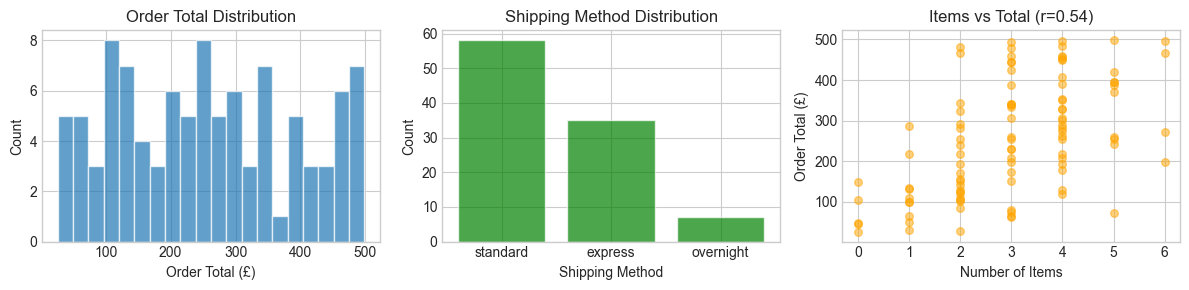


Sample orders:
  Sarah Johnson: 3 items, £78.87, standard
  Michael Brown: 5 items, £393.95, express
  Linda Smith: 2 items, £156.65, standard


In [5]:
orders = await generate_synthetic_data(OrderModel, count=100, seed=42)

# Visualize the generated distributions
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Order total distribution
totals = [o.order_total for o in orders]
axes[0].hist(totals, bins=20, edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Order Total (£)')
axes[0].set_ylabel('Count')
axes[0].set_title('Order Total Distribution')

# Shipping method
shipping = Counter(o.shipping_method for o in orders)
axes[1].bar(shipping.keys(), shipping.values(), edgecolor='white', alpha=0.7, color='green')
axes[1].set_xlabel('Shipping Method')
axes[1].set_ylabel('Count')
axes[1].set_title('Shipping Method Distribution')

# Items vs Total (correlation)
items = [o.number_of_items for o in orders]
axes[2].scatter(items, totals, alpha=0.5, s=30, color='orange')
axes[2].set_xlabel('Number of Items')
axes[2].set_ylabel('Order Total (£)')
axes[2].set_title(f'Items vs Total (r={np.corrcoef(items, totals)[0,1]:.2f})')

plt.tight_layout()
plt.show()

print("\nSample orders:")
for order in orders[:3]:
    print(f"  {order.customer_name}: {order.number_of_items} items, £{order.order_total:.2f}, {order.shipping_method}")

## Healthcare Data Model

In [6]:
patient_description = """
A patient medical record with:
- patient_name and date of birth
- Blood pressure (systolic and diastolic)
- Heart rate (beats per minute)
- BMI
- Cholesterol level
- Risk category (low, moderate, high)
- Primary care notes
"""

PatientModel, patient_code = await generate_model_from_description(
    patient_description,
    model_name="PatientRecord"
)

print(patient_code)

class PatientRecord(BaseModel):
    """A model representing a patient medical record."""

    # LLM-generated fields (semantic content)
    patient_name: str
    date_of_birth: str
    primary_care_notes: str

    # Distribution-sampled fields (statistical patterns)
    systolic_bp: Annotated[int, Normal(mean=120, std=15)]
    diastolic_bp: Annotated[int, Normal(mean=80, std=10)]
    heart_rate: Annotated[int, Normal(mean=72, std=10)]
    bmi: Annotated[float, Normal(mean=25.0, std=4.0)]
    cholesterol_level: Annotated[float, Normal(mean=200, std=30)]
    risk_category: Annotated[str, Categorical(weights={"low": 0.5, "moderate": 0.3, "high": 0.2})]

    # Correlations between distribution fields
    __correlations__ = Correlations(
        ("systolic_bp", "diastolic_bp", 0.85),  # Strong positive (gaussian default)
        ("cholesterol_level", "risk_category", -0.6),  # Negative correlation, risk increases with cholesterol
        ("bmi", "heart_rate", 0.5),  # Moderate positive corr

In [7]:
patients = await generate_synthetic_data(PatientModel, count=3)

for patient in patients:
    print(f"\n{patient.patient_name}")
    for field in PatientModel.model_fields:
        if field != "patient_name":
            val = getattr(patient, field)
            if isinstance(val, float):
                print(f"  {field}: {val:.1f}")
            else:
                print(f"  {field}: {val}")


John Smith
  date_of_birth: 1985-06-15
  primary_care_notes: Patient presents with slightly elevated blood pressure but otherwise maintains a healthy lifestyle.
  systolic_bp: 135
  diastolic_bp: 90
  heart_rate: 89
  bmi: 22.6
  cholesterol_level: 207.6
  risk_category: low

Maria Gonzalez
  date_of_birth: 1975-11-30
  primary_care_notes: Patient is advised to monitor cholesterol and maintain a balanced diet to improve health.
  systolic_bp: 110
  diastolic_bp: 77
  heart_rate: 84
  bmi: 25.7
  cholesterol_level: 200.3
  risk_category: moderate

David Lee
  date_of_birth: 1990-07-22
  primary_care_notes: Patient shows signs of anxiety-related symptoms, suggesting regular check-ups to manage stress.
  systolic_bp: 127
  diastolic_bp: 88
  heart_rate: 57
  bmi: 22.7
  cholesterol_level: 208.7
  risk_category: moderate


## Financial Data Model

In [8]:
transaction_description = """
A financial transaction with:
- Account holder name
- Transaction amount (typically small purchases but occasionally large)
- Transaction type (purchase 70%, transfer 20%, withdrawal 10%)
- Merchant category (retail, food, travel, utilities, entertainment)
- Risk score (0-1, most transactions are low risk)
- Timestamp
- Location
"""

TransactionModel, tx_code = await generate_model_from_description(
    transaction_description,
    model_name="Transaction"
)

print(tx_code)

class Transaction(BaseModel):
    """A financial transaction representation."""

    # LLM-generated fields (semantic content)
    account_holder_name: str
    transaction_type: str
    merchant_category: str
    location: str
    timestamp: str

    # Distribution-sampled fields (statistical patterns)
    transaction_amount: Annotated[float, LogNormal(mean=5, sigma=1)]  # Small purchases but occasionally large
    risk_score: Annotated[float, Beta(alpha=6, beta=4)]  # Most transactions are low risk (0-1)

    # Categorical representation with proportions
    transaction_type: Annotated[str, Categorical(weights={'purchase': 0.7, 'transfer': 0.2, 'withdrawal': 0.1})]
    merchant_category: Annotated[str, Categorical(weights={'retail': 0.3, 'food': 0.3, 'travel': 0.1, 'utilities': 0.2, 'entertainment': 0.1})]

    # Correlations between distribution fields
    __correlations__ = Correlations(
        ('transaction_amount', 'risk_score', 0.5, 'student_t'),  # Moderate correlation, financi

In [9]:
transactions = await generate_synthetic_data(TransactionModel, count=5, seed=42)

for tx in transactions:
    print(f"\n{tx.account_holder_name}")
    for field in TransactionModel.model_fields:
        if field != "account_holder_name":
            val = getattr(tx, field)
            if isinstance(val, float) and "amount" in field.lower():
                print(f"  {field}: £{val:,.2f}")
            elif isinstance(val, float):
                print(f"  {field}: {val:.3f}")
            else:
                print(f"  {field}: {val}")


John Smith
  transaction_type: purchase
  merchant_category: utilities
  location: Los Angeles, CA
  timestamp: 2023-10-15T14:30:00Z
  transaction_amount: £68.06
  risk_score: 0.643

Diana Ross
  transaction_type: purchase
  merchant_category: food
  location: New York, NY
  timestamp: 2023-10-14T11:15:00Z
  transaction_amount: £467.84
  risk_score: 0.751

Emma Brown
  transaction_type: purchase
  merchant_category: utilities
  location: San Francisco, CA
  timestamp: 2023-10-13T09:45:00Z
  transaction_amount: £94.34
  risk_score: 0.682

Michael Johnson
  transaction_type: transfer
  merchant_category: travel
  location: Miami, FL
  timestamp: 2023-10-12T16:20:00Z
  transaction_amount: £203.16
  risk_score: 0.541

Alice Davis
  transaction_type: purchase
  merchant_category: utilities
  location: Seattle, WA
  timestamp: 2023-10-11T18:00:00Z
  transaction_amount: £114.53
  risk_score: 0.558


## Model with Correlations

The LLM can also suggest correlations when you describe relationships:

In [10]:
employee_description = """
An employee record with:
- Name and email
- Age (22-65)
- Years of experience (correlated with age - older employees have more experience)
- Salary (correlated with experience - more experience means higher salary)
- Performance score (0-1)
- Department (Engineering 40%, Product 25%, Sales 20%, Other 15%)
- Job title

Note: Age, experience, and salary should be positively correlated.
"""

EmployeeModel, emp_code = await generate_model_from_description(
    employee_description,
    model_name="Employee"
)

print(emp_code)

class Employee(BaseModel):
    """Represents an employee record with personal and professional information."""

    # LLM-generated fields (semantic content)
    name: str
    email: str
    job_title: str

    # Distribution-sampled fields (statistical patterns)
    age: Annotated[int, Uniform(min=22, max=65)]
    years_experience: Annotated[int, Uniform(min=0, max=40)]
    salary: Annotated[float, Normal(mean=75000, std=15000)]
    performance_score: Annotated[float, Beta(alpha=5, beta=3)]
    department: Annotated[str, Categorical(weights={"Engineering": 0.4, "Product": 0.25, "Sales": 0.2, "Other": 0.15})]

    # Correlations between distribution fields
    __correlations__ = Correlations(
        ("age", "years_experience", 0.85),           # Strong positive (gaussian default)
        ("years_experience", "salary", 0.6),        # Moderate positive
        ("performance_score", "salary", 0.5, "gumbel"),  # Upper tail - high performers get significant raises
    )

    # Optional fie

Correlation analysis:
  Age-Experience: 0.73
  Experience-Salary: 0.63


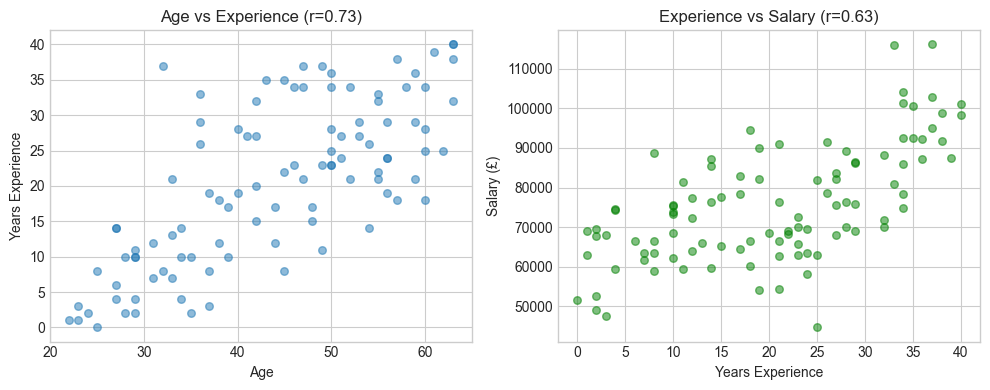


Sample employees:
  John Smith: Age 27, 14 yrs exp, £87,114
  Mary Brown: Age 59, 36 yrs exp, £87,094
  Joe Green: Age 33, 13 yrs exp, £65,965
  Susan Jones: Age 52, 34 yrs exp, £85,935
  Mike Wilson: Age 40, 19 yrs exp, £82,082


In [11]:
employees = await generate_synthetic_data(EmployeeModel, count=100, seed=42)

# Check if correlations were applied
ages = [e.age for e in employees]
exp = [e.years_experience for e in employees]
sal = [e.salary for e in employees]

print("Correlation analysis:")
print(f"  Age-Experience: {np.corrcoef(ages, exp)[0,1]:.2f}")
print(f"  Experience-Salary: {np.corrcoef(exp, sal)[0,1]:.2f}")

# Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(ages, exp, alpha=0.5, s=30)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Years Experience')
axes[0].set_title(f'Age vs Experience (r={np.corrcoef(ages, exp)[0,1]:.2f})')

axes[1].scatter(exp, sal, alpha=0.5, s=30, color='green')
axes[1].set_xlabel('Years Experience')
axes[1].set_ylabel('Salary (£)')
axes[1].set_title(f'Experience vs Salary (r={np.corrcoef(exp, sal)[0,1]:.2f})')

plt.tight_layout()
plt.show()

print("\nSample employees:")
for emp in employees[:5]:
    print(f"  {emp.name}: Age {emp.age}, {emp.years_experience} yrs exp, £{emp.salary:,.0f}")

## Security

Generated code is validated via AST parsing before execution. The following are blocked:
- Import statements
- `exec`, `eval`, `compile`, `open`
- `globals()`, `locals()`, `__builtins__`
- Dunder attribute access (`__class__`, `__bases__`, etc.)

## Tips for Good Descriptions

1. **Be specific about ranges**: "Age (22-65)" is better than "age"
2. **Specify distributions for categories**: "Status (pending 40%, shipped 35%, delivered 25%)"
3. **Mention correlations**: "Experience correlates with salary"
4. **Describe semantic fields**: "Brief professional bio" helps the LLM generate better text
5. **Use domain terminology**: The LLM understands business, medical, financial terms